Shape of observations: (15,)

Running Adaptive Metropolis algorithm for 1000 iterations...
Initial proposal distribution (first 100 iterations): N(q_prev, D) with D = diag([0.01, 2e-10])
AM parameters: sp = 2.38^2/2 = 2.8322, k0 = 100
Running Adaptive Metropolis MCMC...
  Completed 100/1000 iterations, acceptance rate: 0.677

At k=101, computed Vk from first 100 samples:
Vk = [[7.93030677e-01 3.34840269e-05]
 [3.34840269e-05 2.24989131e-09]]
  Completed 200/1000 iterations, acceptance rate: 0.432
  Completed 300/1000 iterations, acceptance rate: 0.355
  Completed 400/1000 iterations, acceptance rate: 0.296
  Completed 500/1000 iterations, acceptance rate: 0.263
  Completed 600/1000 iterations, acceptance rate: 0.259
  Completed 700/1000 iterations, acceptance rate: 0.256
  Completed 800/1000 iterations, acceptance rate: 0.253
  Completed 900/1000 iterations, acceptance rate: 0.249
  Completed 1000/1000 iterations, acceptance rate: 0.236

Final acceptance rate: 0.236

PROBLEM 2.1 RESULT

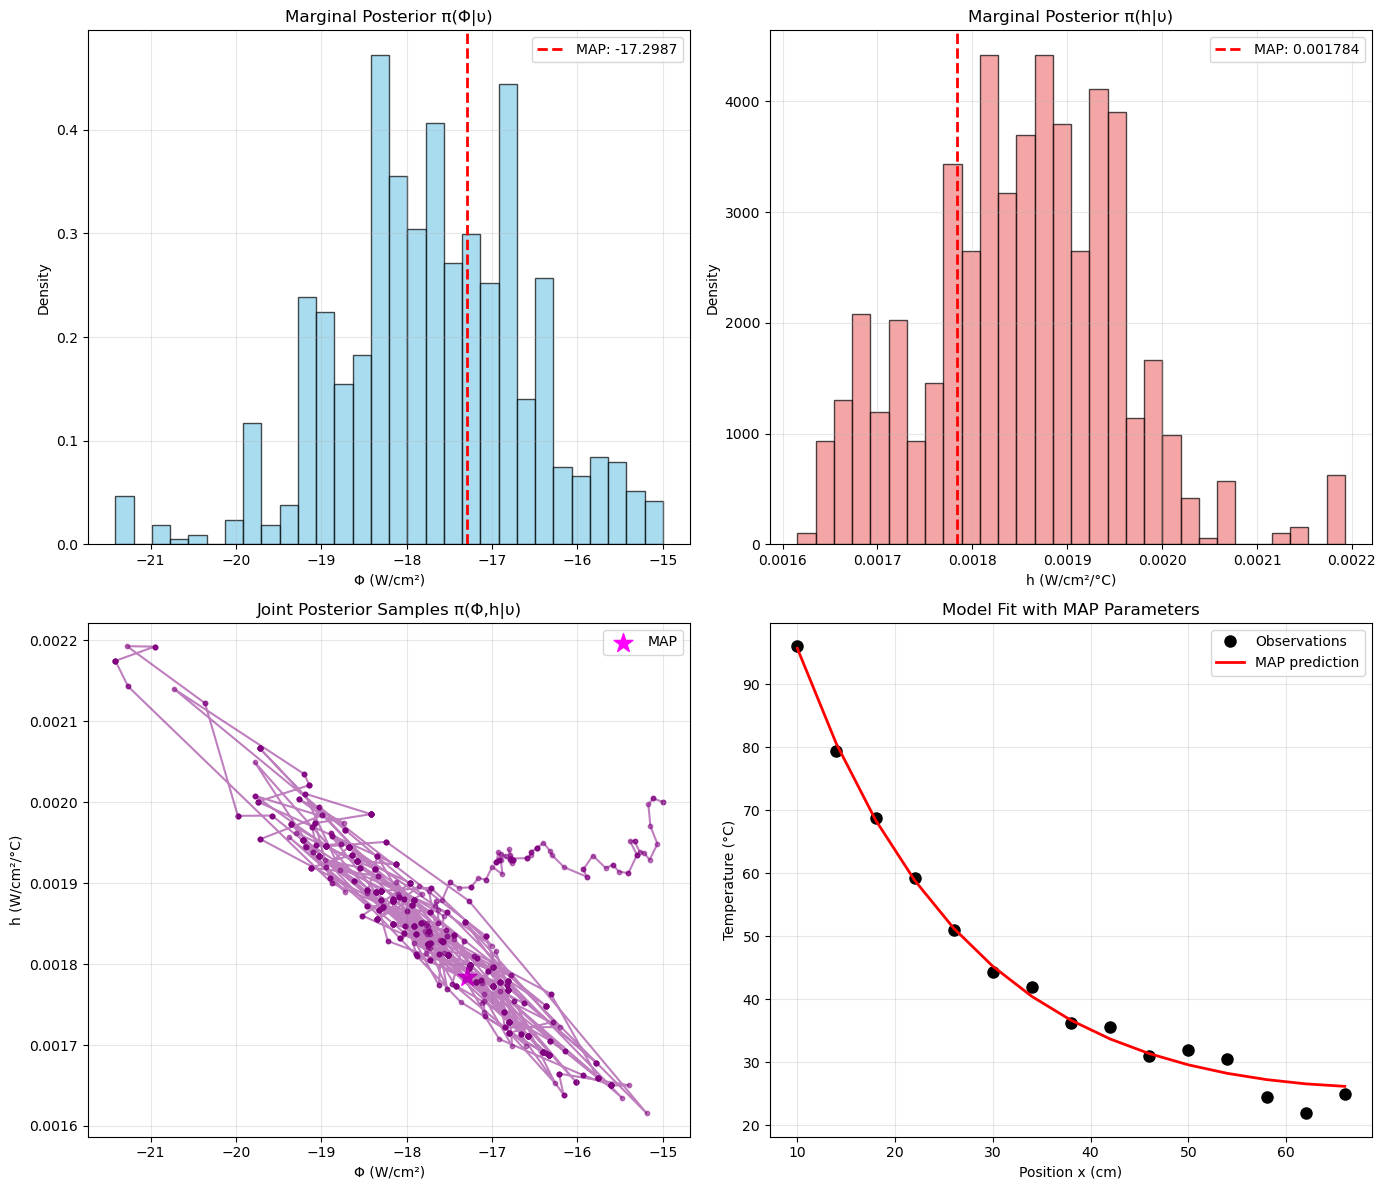


Results saved to 'problem2.1_results.npz'


0.23623623623623624

In [5]:
import os, sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('../hw1')
import heat_rod as hr
from mcmc import *
from am_mcmc import *
from scipy.io import loadmat

data = loadmat("HW06_Problem1.mat")
samples, posterior_values, q_map, Vk_at_101, acceptance_rate = run_adaptive_metropolis_for_heat_equation(M=1000)

# Save results
np.savez('problem2.1_results.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)

print(f"\nResults saved to 'problem2.1_results.npz'")
acceptance_rate

At k=101, the new Vk generated from the first 100 samples is:
$V_k = [[7.93e^{-01}, 3.35e^{-05}]; 
 [3.35e^{-05}, 2.25e^{-09}]]$


# 2.2

At k=M = 1000, the new Vk generated from the first 1000 samples is:
$V_k = [[ 1.28e^{+00}, -8.54e^{-05}];
 [-8.54e^{-05}  1.00e^{-08}]]$


# 2.3

The MAP point is [  Φ = -17.298689 W/cm²,  h = 0.001784 W/cm²/°C]. The final acceptance ratio is: 0.268. 

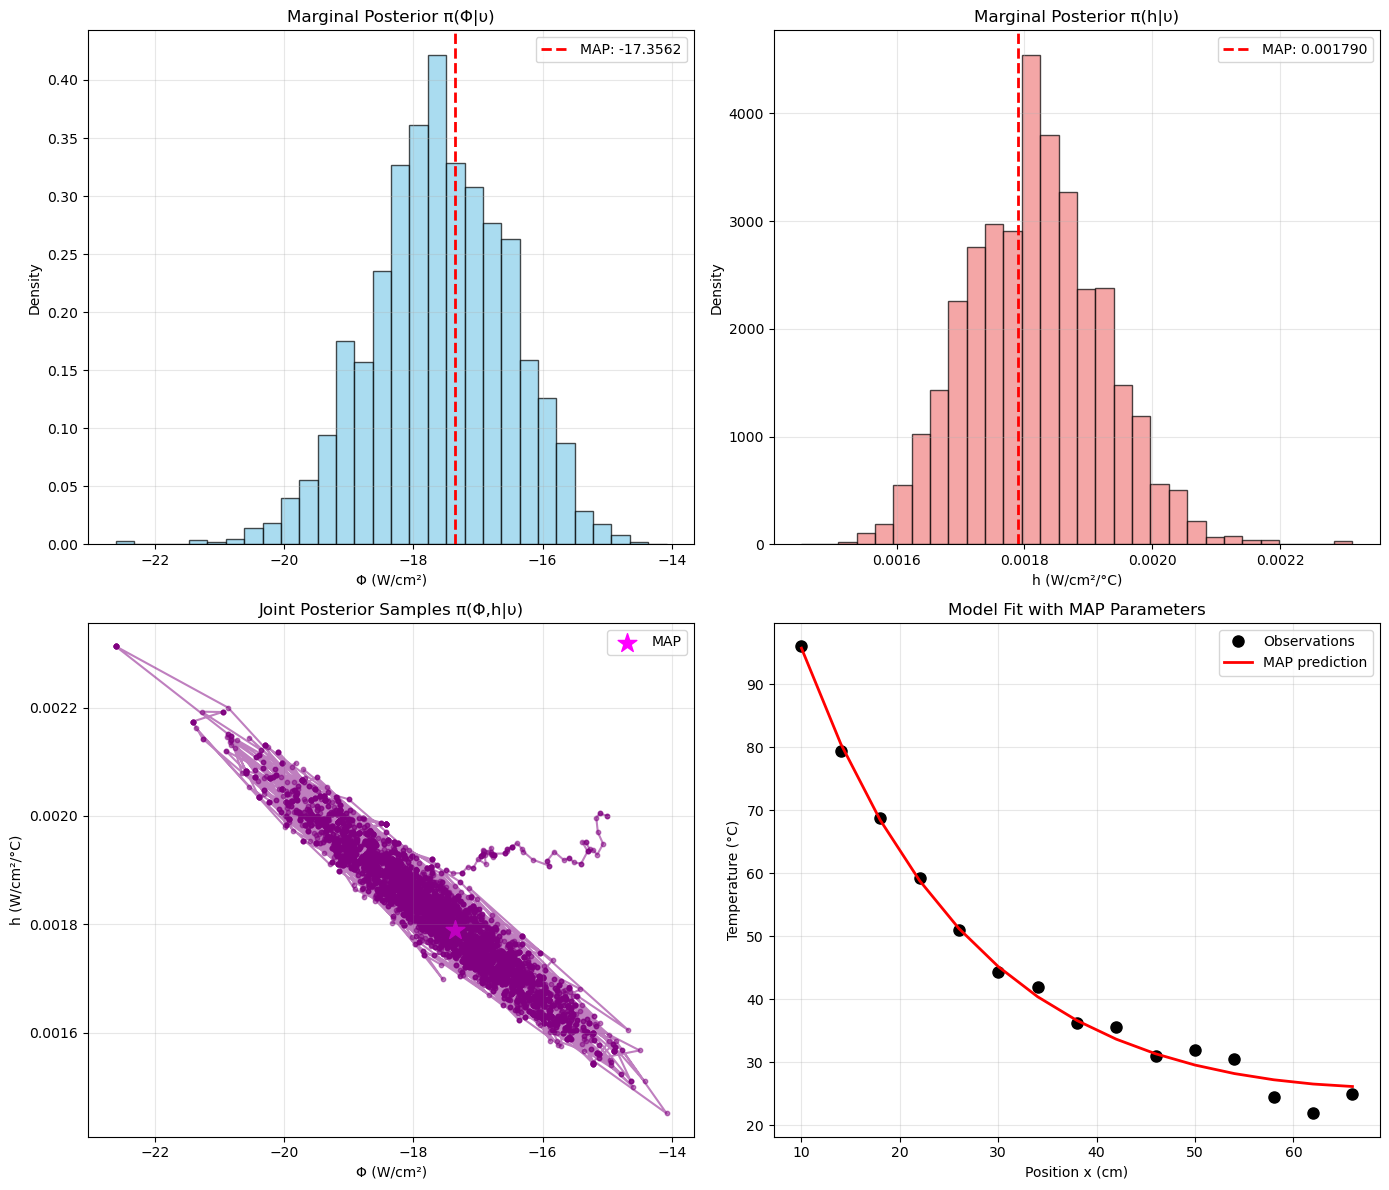

# 2.4
The acceptance pattern shows a well-behaved adaptive MCMC tuning process: the acceptance rate starts high (0.43), meaning the initial proposal steps are too small, then steadily decreases as the algorithm increases the proposal scale to explore more efficiently. Around 1000–2000 iterations it stabilizes near ~0.22–0.23, which is close to the theoretical optimal value (~0.234 for high-dimensional random-walk Metropolis), indicating a good tuning. After that, it slowly drifts upward and stabilizes around ~0.26–0.27, suggesting adaptation continued adjusting covariance structure (not just scale), slightly improving move efficiency. Overall, this shows convergence from an over-conservative proposal to a near-optimal one, followed by mild fine-tuning and stabilization.



With 100,000 samples from the previous problem, the most accurate estimate of $q_{MAP}$ is $[Φ = -17.375 W/cm², h = 0.00179 W/cm²/°C]$. From the previous MCMC algorithm, with 1000 samples, we get $q_{MAP, MCMC, 1000} = [ Φ = -17.560 W/cm²,  h = 0.0018 W/cm²/°C]$. Now, with the adaptive algorithm and a sample size of 1000, we get 
The MAP point is $q_{MAP, AM-MCMC, 1000} = [ Φ = -17.298 W/cm²,  h = 0.0018 W/cm²/°C]$. Notice that with the same number of samples, the adaptive method gives a far better MAP estimate than the standard MCMC method.

Using Adaptive Metropolis (AM) significantly improves efficiency compared to standard Metropolis--Hastings with a fixed proposal covariance $D$. In standard MH, performance is highly sensitive to the manual choice of $D$; if $D$ is poorly scaled, the chain either moves too slowly (high acceptance but strong correlation) or rejects too often (low acceptance and poor exploration). With AM, the proposal covariance $V_k$ adapts to the empirical covariance of the samples, automatically learning the posterior scale and correlation structure between $\Phi$ and $h$. Consequently, the acceptance ratio typically stabilizes near the optimal range (approximately $0.23$--$0.30$ for $p=2$), mixing improves, autocorrelation decreases, and the chain reaches the high-density region more quickly (shorter effective burn-in). The MAP estimate itself generally does not change very significantly, since the target distribution is unchanged, but it is obtained more reliably and efficiently with improved exploration of the posterior. Overall, AM increases robustness, reduces manual tuning, and yields more efficient sampling than fixed-covariance Metropolis--Hastings.